[Full Caunagi seed 1] 读取: /disk1/cai029/CauNagi/Benchmark/Benchmark_Disentangled/Ablation/use_data/Caunagi_temp_path_1/1/stagedata/dataset.h5ad
  → obsm keys: ['X_umap', 'umap', 'z']
  → obs columns (前30): ['barcode', 'nUMI', 'nGene', 'percMito', 'percSpliced.v', 'percUnspliced.v', 'percAmbiguous.v', 'Sample.ID', 'Subject.ID', 'Sex', 'Age', 'Surface.Density', 'Percent.Tissue', 'Disease.Ident', 'nCount_RNA', 'final.ident', 'nFeature_RNA', 'nCount_integrated', 'nFeature_integrated', 'name.simple', 'Library.Ident', 'renamedFin', 'integrated_snn_res.2', 'seurat_clusters', 'renamed.2', 'integrated_snn_res.3', 'log10UMI', 'renamed.3', 'stage', 'leiden']
[Full Caunagi seed 2] 读取: /disk1/cai029/CauNagi/Benchmark/Benchmark_Disentangled/Ablation/use_data/Caunagi_temp_path_2/1/stagedata/dataset.h5ad
[Full Caunagi seed 3] 读取: /disk1/cai029/CauNagi/Benchmark/Benchmark_Disentangled/Ablation/use_data/Caunagi_temp_path_3/1/stagedata/dataset.h5ad
[Full Caunagi seed 4] 读取: /disk1/cai029/CauNagi/Benchmar

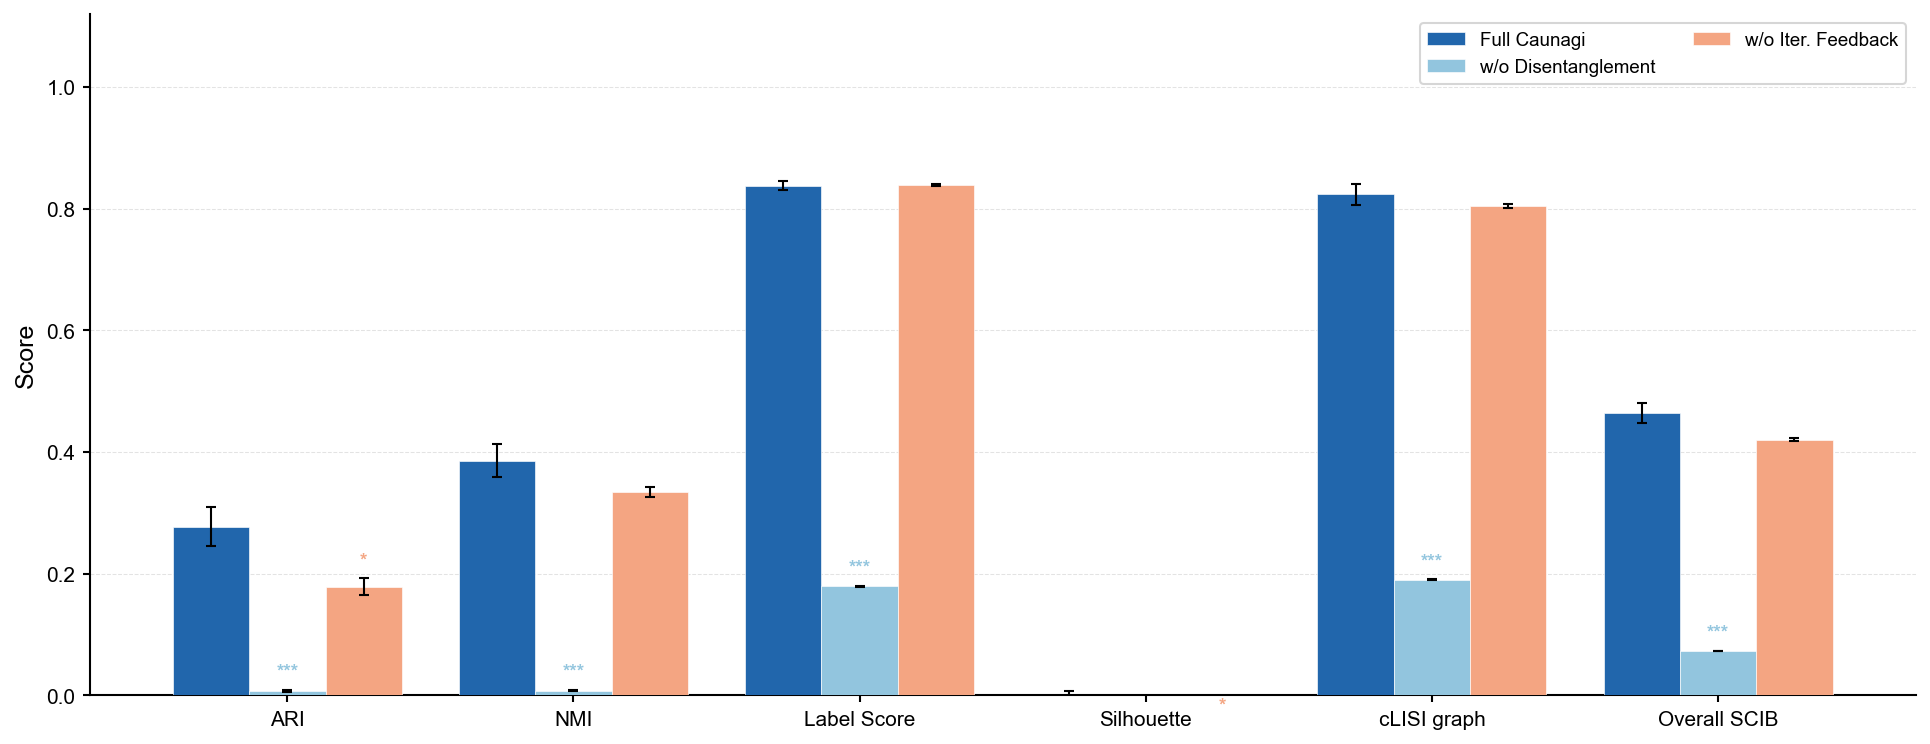


图表已保存为 figure3_ablation.pdf / .png


In [11]:
"""
figure3_ablation.py — 消融实验柱状图
=====================================
从 4 个变体 × 5 个种子的 h5ad 文件中提取潜在特征，
计算 6 项 benchmark 指标，绘制分组柱状图+误差棒+显著性标注。

使用前请确认以下配置项与你的实际数据一致：
  - BASE_PATH: 数据根目录
  - CELLTYPE_COL: obs 中细胞类型标签的列名
  - CLUSTER_COL: obs 中聚类标签的列名
  - LATENT_KEY: 潜在特征在 obsm 或 obs 中的 key
"""

import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

# =========================== 0. 全局样式 ===========================
matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# =========================== 1. 配置 ===========================

BASE_PATH = "/disk1/cai029/CauNagi/Benchmark/Benchmark_Disentangled/Ablation/use_data"

# 变体名 → 文件夹前缀的映射
VARIANT_FOLDERS = {
    "Full Caunagi":          "Caunagi",
    "w/o Disentanglement":   "w_o_Disentanglement",
    "w/o Iter. Feedback":    "w_o_Iterative_Feedback",
}

N_SEEDS = 5        # 种子数
CELLTYPE_COL = "celltype"   # ← 按你的实际列名改
CLUSTER_COL  = "leiden"     # ← 按你的实际列名改
LATENT_KEY   = "z"          # ← 按你的实际 key 改（obsm 或 obs 中）

VARIANTS_ORDER = [
    "Full Caunagi",
    "w/o Disentanglement",
    "w/o Iter. Feedback",
]
METRICS_ORDER = [
    "ARI", "NMI", "Label Score", "Silhouette",
    "cLISI graph", "Overall SCIB",
]
COLORS = ["#2166AC", "#92C5DE", "#F4A582", "#CA0020"]


# =========================== 2. 数据加载 ===========================

def get_latent_features(adata):
    """从 h5ad 提取潜在特征。先查 obsm，再查 obs 列。"""
    if LATENT_KEY in adata.obsm:
        return adata.obsm[LATENT_KEY]
    if LATENT_KEY in adata.obs.columns:
        col = adata.obs[LATENT_KEY]
        # 处理每行是一个 array/list 的情况
        first = col.iloc[0]
        if isinstance(first, (np.ndarray, list)):
            return np.stack(col.values)
        # 处理每行是标量的情况（不太可能但做防御）
        return col.values.astype(float).reshape(-1, 1)
    raise KeyError(
        f"'{LATENT_KEY}' 不在 adata.obsm 也不在 adata.obs.columns 中。"
        f"可用 obsm keys: {list(adata.obsm.keys())}; "
        f"obs columns: {list(adata.obs.columns[:20])}..."
    )


def compute_ari(adata):
    true = LabelEncoder().fit_transform(adata.obs[CELLTYPE_COL].astype(str))
    pred = LabelEncoder().fit_transform(adata.obs[CLUSTER_COL].astype(str))
    return adjusted_rand_score(true, pred)


def compute_nmi(adata):
    true = LabelEncoder().fit_transform(adata.obs[CELLTYPE_COL].astype(str))
    pred = LabelEncoder().fit_transform(adata.obs[CLUSTER_COL].astype(str))
    return normalized_mutual_info_score(true, pred)


def compute_label_score(adata):
    """KNN 5折交叉验证：用潜在特征预测细胞类型标签，返回平均准确率。"""
    X = get_latent_features(adata)
    y = LabelEncoder().fit_transform(adata.obs[CELLTYPE_COL].astype(str))
    if len(set(y)) < 2:
        return np.nan
    knn = KNeighborsClassifier(n_neighbors=5)
    try:
        scores = cross_val_score(knn, X, y, cv=min(5, min(np.bincount(y))), scoring="accuracy")
        return scores.mean()
    except ValueError:
        knn.fit(X, y)
        return knn.score(X, y)


def compute_silhouette(adata):
    X = get_latent_features(adata)
    labels = LabelEncoder().fit_transform(adata.obs[CLUSTER_COL].astype(str))
    if len(set(labels)) < 2 or len(labels) < 2:
        return np.nan
    # 数据量大时降采样以减少计算量
    if len(X) > 10000:
        idx = np.random.default_rng(42).choice(len(X), 10000, replace=False)
        X, labels = X[idx], labels[idx]
    return silhouette_score(X, labels)


def compute_clisi(adata):
    """
    cLISI graph。优先使用 scib 包；若无 scib，使用简化 k-NN purity 代替。
    """
    X = get_latent_features(adata)
    y = LabelEncoder().fit_transform(adata.obs[CELLTYPE_COL].astype(str))
    try:
        # 尝试用 scib（如果你装了的话）
        from scib.metrics import clisi_graph as scib_clisi
        # 返回结果可能是一个标量或 Series，统一处理
        result = scib_clisi(adata, label_key=CELLTYPE_COL, type_="embed",
                            use_rep=LATENT_KEY if LATENT_KEY in adata.obsm else "X_emb")
        if hasattr(result, 'mean'):
            return float(np.mean(result))
        return float(result)
    except (ImportError, Exception):
        # 降级为 k-NN purity
        pass
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=30).fit(X)
    indices = nn.kneighbors(X, return_distance=False)
    purities = [np.mean(y[indices[i]] == y[i]) for i in range(len(y))]
    return float(np.mean(purities))


def compute_scib_overall(adata):
    """
    Overall SCIB。需要 scib 包。
    如果你在原始 benchmark 中有自己的计算方式，替换这里。
    """
    try:
        import scib
        # TODO: 替换为你的 scib 综合指标计算方式
        return np.nan
    except ImportError:
        return (compute_ari(adata) + compute_nmi(adata) + compute_label_score(adata) + compute_silhouette(adata) + compute_clisi(adata)) / 5


# 指标名 → 计算函数的字典
METRIC_FUNCTIONS = {
    "ARI":            compute_ari,
    "NMI":            compute_nmi,
    "Label Score":    compute_label_score,
    "Silhouette":     compute_silhouette,
    "cLISI graph":    compute_clisi,
    "Overall SCIB":   compute_scib_overall,
}


# =========================== 3. 主流程 ===========================

def load_and_compute_all():
    """遍历所有 h5ad 文件，计算全部指标，返回 DataFrame。"""
    records = []
    for variant_display, prefix in VARIANT_FOLDERS.items():
        for seed_idx in range(1, N_SEEDS + 1):
            path = os.path.join(
                BASE_PATH,
                f"{prefix}_temp_path_{seed_idx}",
                "1", "stagedata", "dataset.h5ad",
            )
            print(f"[{variant_display} seed {seed_idx}] 读取: {path}")
            if not os.path.exists(path):
                print(f"  !! 文件不存在，跳过")
                continue
            adata = sc.read_h5ad(path)

            # 初次读取时打印可用列名，方便你确认 COL 配置是否正确
            if seed_idx == 1 and variant_display == VARIANTS_ORDER[0]:
                print(f"  → obsm keys: {list(adata.obsm.keys())}")
                print(f"  → obs columns (前30): {list(adata.obs.columns[:30])}")

            for metric_name, metric_fn in METRIC_FUNCTIONS.items():
                try:
                    val = metric_fn(adata)
                except Exception as e:
                    print(f"  !! {metric_name} 计算失败: {e}")
                    val = np.nan
                records.append({
                    "variant": variant_display,
                    "metric":  metric_name,
                    "value":   val,
                    "seed":    seed_idx,
                })
    return pd.DataFrame(records)


# =========================== 4. 显著性检验 ===========================

def compute_significance(df):
    """对每个 (metric, ablation_variant) 做配对 t 检验 vs Full Caunagi。"""
    pivot_full = df[df["variant"] == "Full Caunagi"].pivot(
        index="seed", columns="metric", values="value"
    )
    sig = {}
    ablation_variants = VARIANTS_ORDER[1:]  # 除 Full 外三个
    for v in ablation_variants:
        pivot_v = df[df["variant"] == v].pivot(
            index="seed", columns="metric", values="value"
        )
        common = pivot_full.index.intersection(pivot_v.index)
        if len(common) < 3:
            for m in METRICS_ORDER:
                sig[(m, v)] = 1.0
            continue
        for m in METRICS_ORDER:
            a = pivot_full.loc[common, m].dropna().values
            b = pivot_v.loc[common, m].dropna().values
            if len(a) < 3 or len(b) < 3:
                sig[(m, v)] = 1.0
                continue
            _, p = stats.ttest_rel(a, b)
            sig[(m, v)] = p
    return sig


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return None


# =========================== 5. 绘图 ===========================

def plot_ablation(df, sig_dict, save_path="figure3_ablation.pdf"):
    summary = (
        df.groupby(["variant", "metric"])["value"]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    summary["sem"] = summary["std"] / np.sqrt(summary["count"])

    # 打印汇总表，方便检查
    print("\n=== 各指标均值 ===")
    print(summary.pivot(index="variant", columns="metric", values="mean").round(4))

    fig, ax = plt.subplots(figsize=(13, 5.2))
    x = np.arange(len(METRICS_ORDER))
    n_var = len(VARIANTS_ORDER)
    total_width = 0.80
    bar_w = total_width / n_var

    for v_idx, (variant, color) in enumerate(zip(VARIANTS_ORDER, COLORS)):
        means, sems = [], []
        for m in METRICS_ORDER:
            row = summary[(summary["variant"] == variant) & (summary["metric"] == m)]
            means.append(row["mean"].values[0] if not row.empty else 0)
            sems.append(row["sem"].values[0] if not row.empty else 0)

        offset = (v_idx - (n_var - 1) / 2) * bar_w
        ax.bar(
            x + offset, means, bar_w, yerr=sems,
            label=variant, color=color,
            edgecolor="white", linewidth=0.3,
            capsize=2.5,
            error_kw={"linewidth": 1.0, "color": "#555555"},
            zorder=3,
        )

        # 显著性星号
        if variant != "Full Caunagi":
            for m_idx, m in enumerate(METRICS_ORDER):
                p = sig_dict.get((m, variant), 1.0)
                stars = p_to_stars(p)
                if stars:
                    ax.text(
                        x[m_idx] + offset,
                        means[m_idx] + sems[m_idx] + 0.015,
                        stars, ha="center", va="bottom",
                        fontsize=9, fontweight="bold", color=color,
                    )

    ax.set_xticks(x)
    ax.set_xticklabels(METRICS_ORDER)
    ax.set_ylabel("Score", fontweight="medium")
    ax.set_ylim(0, 1.12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, linewidth=0.5)
    ax.set_axisbelow(True)

    ax.legend(
        loc="upper right", ncol=2, frameon=True, edgecolor="#cccccc"
    )

    # fig.text(
    #     0.5, -0.02,
    #     "n = 5 independent runs per variant; stars: paired t-test vs Full Caunagi ("
    #     "*p<0.05, **p<0.01, ***p<0.001)",
    #     ha="center", fontsize=7.5, color="#666666",
    # )
    plt.tight_layout(rect=[0, 0.02, 1, 1])
    plt.savefig(save_path, dpi=300)
    plt.savefig(save_path.replace(".pdf", ".png"), dpi=300)
    plt.show()


# =========================== 6. 入口 ===========================

if __name__ == "__main__":
    df = load_and_compute_all()
    
    # 保存原始数据，防止反复重算
    df.to_csv("ablation_results.csv", index=False)
    print(f"\n原始数据已保存至 ablation_results.csv ({len(df)} 行)")

    sig = compute_significance(df)
    print("\n=== 显著性矩阵 (p值) ===")
    print(pd.DataFrame(
        {(m, v): f"{sig[(m, v)]:.4f}" for m in METRICS_ORDER for v in VARIANTS_ORDER[1:]},
        index=METRICS_ORDER,
    ))

    plot_ablation(df, sig)
    print("\n图表已保存为 figure3_ablation.pdf / .png")